# Identification

<a target="_blank" href="https://colab.research.google.com/github/glaucogoncalves/nio/blob/main/assignments/ilp-exec-3.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jussiléa Gurjão de Figueiredo - Isolada05

# Attention, please!

Solve the problems below. Show the problem model and the solution using ```pyomo``` and the GLPK or COIN-OR solvers.

To see how to write optimization models in colab, look for examples in the Integer Linear Programming class colab.

Please send your Colab file (.ipynb) in SIGAA.

# Problem 1

Considering graph of routers of the RNP's network, which is [presented here](https://redeipe.rnp.br/panorama). From this picture code a solution that find the shortest path between routers **PE** and **GO**. You should model the graph in the colab using the library networkx (see the colab on ILP for an example of usage). You must solve the problem in two ways: by solver and using Djikstra's Algorithm (networkx implements that). Compare the solutions found and the time to obtain each one. Please set the weights as $w_{ij} = \frac{1}{\text{link capacity}}$. The link capacity can be obtained if you hover the mouse pointer over a link in the site.

In [78]:
!pip install -q pyomo
!apt install coinor-cbc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
coinor-cbc is already the newest version (2.10.7+ds1-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [79]:
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pyomo.environ import *
import math

In [80]:
# Dados do problema

nodes = ['AC','AL','AM','AP','BA','CE','DF','ES','GO','MA','MG','MS','MT','PA','PB_CGE','PB_JPA','PE','PI','PR','RJ','RN','RO','RR','RS','SC','SE','SP','TO']

edges = [('AC','RO',0.01),('RO','MT',0.01),('MT','DF',0.01),('MT','GO',0.1),('MT','MS',0.01),('MS','GO',0.01),('MS','PR',0.1),('GO','DF',0.005),('DF','AM',0.111),('DF','MA',0.01),('DF','TO',0.005),
         ('DF','BA',0.01),('DF','MG',0.01),('DF','SP',0.005),('AM','RR',0.01),('AM','AP',0.005),('RO','AM',0.0111),('DF','CE',0.1),('RR','CE',1),('CE','RN',0.01),('CE','PI',0.01),('CE','BA',0.01),
         ('CE','SP',0.003),('RN','PB_CGE',0.01),('AP','PA',0.01),('MT','MS',0.01),('PI','MA',0.01),('PI','BA',0.01),('SC','PR',0.005),('SC','SP',0.01),('SC','RS',0.01),('PR','SP',0.003),('PR','RS',0.005),
         ('TO','PA',0.01),('PA','MA',0.1),('PB_CGE','PE',0.01),('PB_CGE','PB_JPA',0.005),('PB_CGE','BA',0.025),('MG','SP',0.01),('MG','RJ',0.005),('MG','ES',0.1),('MG','BA',0.01),('PB_JPA','PE',0.1),
         ('RS','SP',0.01),('SP','RJ',0.005),('RJ','ES',0.01),('ES','PA',0.0033),('BA','SE',0.01),('SE','AL',0.01),('AL','PE',0.01)]


In [81]:
arcs = []

# grafo não direcionado
for i,j,w in edges:
    arcs.append((i,j,w))
    arcs.append((j,i,w))

model = ConcreteModel()

model.N = Set(initialize=nodes) # conjunto de nós
model.A = Set(initialize=[(i,j) for (i,j,w) in arcs]) # conjunto de arcos

weights = {(i,j):w for (i,j,w) in arcs}

model.w = Param(model.A, initialize=weights) # parâmetro peso

model.x = Var(model.A, domain=Binary) # variável de decisão

def obj_rule(model):
    return sum(model.w[i,j]*model.x[i,j] for (i,j) in model.A) # função objetivo

model.obj = Objective(rule=obj_rule, sense=minimize)

source = 'PE'
target = 'GO'

def flow_rule(model,n):

    inflow = sum(model.x[i,j] for (i,j) in model.A if j==n)
    outflow = sum(model.x[i,j] for (i,j) in model.A if i==n)

    if n == source: # restrição de conservação de fluxo
        return outflow - inflow == 1

    elif n == target:
        return inflow - outflow == 1

    else:
        return inflow - outflow == 0

model.flow = Constraint(model.N, rule=flow_rule)



In [82]:
solver = SolverFactory('cbc')

solver_edges = []

# medir somente o tempo de resolução do solver
start_solver = time.time()
results = solver.solve(model)
end_solver = time.time()

time_solver = end_solver - start_solver

# extrair arestas selecionadas pelo solver
for (i,j) in model.A:
    if model.x[i,j].value > 0.5:
        solver_edges.append((i,j))

# reconstruir caminho ordenado
path = ['PE']
current = 'PE'

while current != 'GO':
    for (i,j) in solver_edges:
        if i == current:
            path.append(j)
            current = j
            break

print("Caminho solver:", path)
print("Tempo solver:", time_solver)

Caminho solver: ['PE', 'PB_CGE', 'RN', 'CE', 'SP', 'DF', 'GO']
Tempo solver: 0.044510602951049805


In [83]:
G = nx.Graph()

for i,j,w in edges:
    G.add_edge(i,j,weight=w)

In [84]:
start_dijkstra = time.time()

path = nx.dijkstra_path(G,'PE','GO',weight='weight')
dist = nx.dijkstra_path_length(G,'PE','GO',weight='weight')

end_dijkstra = time.time()

time_dijkstra = end_dijkstra - start_dijkstra

print("Caminho Dijkstra:", path)
print("Distância:", dist)
print("Tempo Dijkstra:", time_dijkstra)

Caminho Dijkstra: ['PE', 'PB_CGE', 'RN', 'CE', 'SP', 'DF', 'GO']
Distância: 0.043
Tempo Dijkstra: 0.0003223419189453125


/tmp/ipykernel_9938/866023042.py:14: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/tmp/ipykernel_9938/866023042.py:24: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


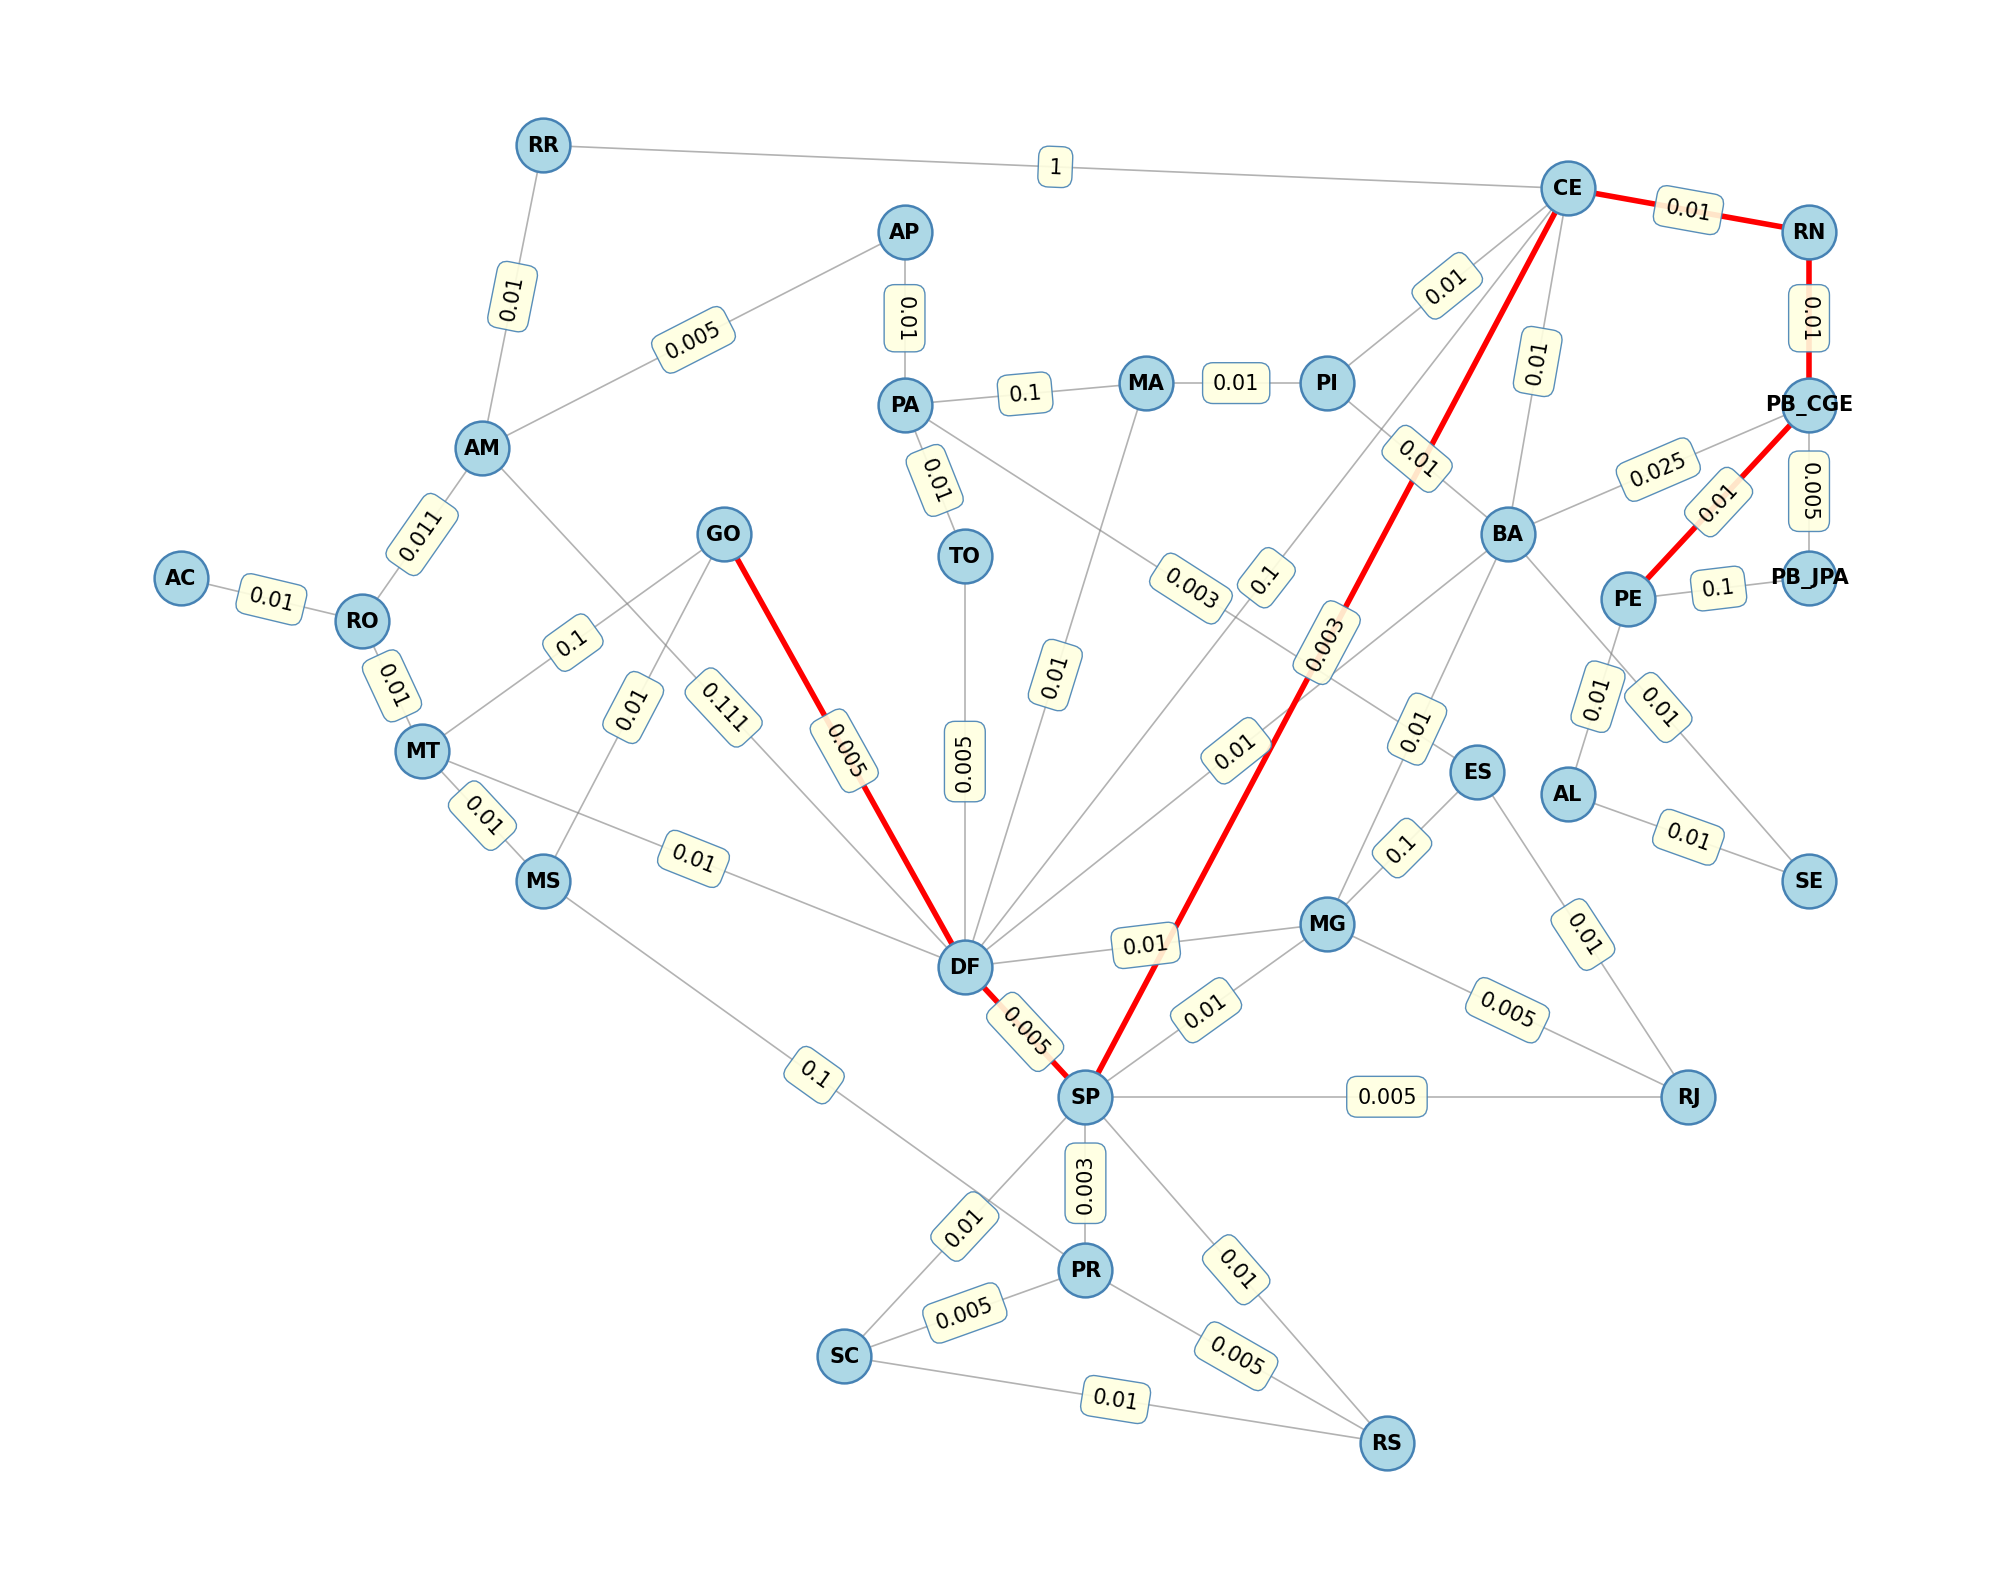

In [85]:
# converter caminho em lista de arestas
path_edges = list(zip(path[:-1], path[1:]))

plt.figure(figsize=(20, 16))


pos = {'AC': (-13, 1),'RO': (-10, 0),'AM': (-8, 4),'RR': (-7, 11),'AP': (-1, 9),'PA': (-1, 5),'TO': (0, 1.5),'MT': (-9, -3),'MS': (-7, -6),'GO': (-4, 2),'DF': (0, -8),'MG': (6, -7),'ES': (8.5, -3.5),
    'RJ': (12, -11),'SP': (2, -11),'PR': (2, -15),'SC': (-2, -17),'RS': (7, -19),'MA': (3, 5.5),'PI': (6, 5.5),'CE': (10, 10),'RN': (14, 9),'PB_CGE': (14, 5),'PB_JPA': (14, 1),'PE': (11, 0.5),
    'AL': (10, -4),'SE': (14, -6),'BA': (9, 2),}

ax = plt.gca()

# arestas normais
nx.draw_networkx_edges(
    G, pos,
    edge_color='gray',
    width=1.2,
    alpha=0.6,
    connectionstyle='arc3,rad=0.08',
    ax=ax
)

# arestas do caminho em vermelho
nx.draw_networkx_edges(
    G, pos,
    edgelist=path_edges,
    edge_color='red',
    width=4,
    connectionstyle='arc3,rad=0.08',
    ax=ax
)

# nós
nx.draw_networkx_nodes(
    G, pos,
    node_color='lightblue',
    node_size=1500,
    edgecolors='steelblue',
    linewidths=1.8,
    ax=ax
)

# labels dos nós
nx.draw_networkx_labels(
    G, pos,
    font_size=15,
    font_weight='bold',
    ax=ax
)

# pesos
labels = {(i,j):round(w,3) for (i,j,w) in edges}

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=labels,
    font_size=15,
    bbox=dict(
        boxstyle='round,pad=0.5',
        fc='lightyellow',
        ec='steelblue',
        alpha=0.9
    ),
    ax=ax
)

plt.axis('off')
plt.tight_layout()
plt.show()

In [86]:
print("COMPARAÇÃO")

print("Tempo solver CBC:", time_solver)
print("Tempo Dijkstra:", time_dijkstra)

COMPARAÇÃO
Tempo solver CBC: 0.044510602951049805
Tempo Dijkstra: 0.0003223419189453125


# Problem 2

A large supermarket chain in the UK needs to build warehouses for a set of supermarkets it is opening in Northern England. The locations of the supermarkets have been identified, but the locations of the warehouses have yet to be determined.

Several good candidate locations for the warehouses have been identified, but decisions must be made regarding how many warehouses to open and at which candidate locations to build them. Moreover, each supermarket has an specific demand that must be met by the warehouses. If one warehouse is not sufficient to meet the demand, other warehouses can chosen to supply the supermarket.

Opening many warehouses would be advantageous as this would reduce the average distance a truck has to drive from the warehouse to the supermarket, and hence reduce the delivery cost. However, opening a warehouse has a fixed cost associated with it.

Our goal is **to find the optimal tradeoff between delivery costs and the costs of building new facilities**.

Below is the set of supermarkets. The coordinates and demand of each supermarket are provided in the following table.

| <i></i> | Coordinates | Demand |
| --- | --- | --- |
| Supermarket 1 | (0,1.5) | 16,000 |
| Supermarket 2 | (2.5,1.2) | 18,000 |
| Supermarket 3 | (4,4) | 12,000 |
| Supermarket 3 | (1.0,1.3) | 17,000 |
| Supermarket 3 | (1.5,2.2) | 20,000 |

The following table shows the coordinates of the candidate warehouse sites, the fixed cost of building the warehouse in millions dollar, and its respective capacity.

| <i></i> | coordinates | fixed cost | Capacity |
| --- | --- |  --- | --- |
| Warehouse 1 | (0,0) | 3 | 30,000 |
| Warehouse 2 | (0,1) | 2 | 10,000 |
| Warehouse 3 | (0,2) | 3 | 12,000 |
| Warehouse 4 | (1,0) | 1 | 8,000 |
| Warehouse 5 | (1,1) | 3 | 15,000 |
| Warehouse 6 | (1,2) | 3 | 22,000 |
| Warehouse 7 | (2,0) | 4 | 10,000 |
| Warehouse 8 | (2,1) | 3 | 30,000 |
| Warehouse 9 | (2,2) | 2 | 20,000 |

The transport cost is one million dollar per kilometer.

Formulate an ILP model and solve it.

In [87]:
# Dados do problema

# Supermercados (x, y, demanda)
supermarkets = { 1: {"coord": (0, 1.5), "demand": 16000}, 2: {"coord": (2.5, 1.2), "demand": 18000}, 3: {"coord": (4, 4), "demand": 12000},
                4: {"coord": (1.0, 1.3), "demand": 17000}, 5: {"coord": (1.5, 2.2), "demand": 20000},}
# Armazéns candidatos (x, y, custo fixo, capacidade)
warehouses = { 1: {"coord": (0,0), "cost": 3, "cap": 30000}, 2: {"coord": (0,1), "cost": 2, "cap": 10000}, 3: {"coord": (0,2), "cost": 3, "cap": 12000},
              4: {"coord": (1,0), "cost": 1, "cap": 8000}, 5: {"coord": (1,1), "cost": 3, "cap": 15000}, 6: {"coord": (1,2), "cost": 3, "cap": 22000},
               7: {"coord": (2,0), "cost": 4, "cap": 10000}, 8: {"coord": (2,1), "cost": 3, "cap": 30000}, 9: {"coord": (2,2), "cost": 2, "cap": 20000},}

# 1 milhão USD/km
transport_cost_per_km = 1 # milhão de dólares/km

In [88]:
# Distâncias
distance = {}
for i in warehouses:
  for j in supermarkets:
    wx, wy = warehouses[i]["coord"]
    sx, sy = supermarkets[j]["coord"]

    d = math.sqrt((wx-sx)**2 + (wy-sy)**2)
    distance[(i,j)] = d

In [89]:
# Modelo
model = ConcreteModel()

model.W = Set(initialize=warehouses.keys())
model.S = Set(initialize=supermarkets.keys())

# variável binária: abrir armazém
model.y = Var(model.W, domain=Binary)

# fluxo de produtos
model.x = Var(model.W, model.S, domain=NonNegativeReals)

# Função objetivo
def obj_rule(m):

    transport = sum(
        distance[(i,j)] * transport_cost_per_km * m.x[i,j]
        for i in m.W for j in m.S
    )

    fixed = sum(
        warehouses[i]["cost"] * m.y[i]
        for i in m.W
    )

    return transport + fixed

model.obj = Objective(rule=obj_rule, sense= minimize)

# Demanda deve ser atendida
def demand_rule(m, j):
    return sum(m.x[i,j] for i in m.W) == supermarkets[j]["demand"]

model.demand = Constraint(model.S, rule=demand_rule)

# Capacidade do armazém
def capacity_rule(m, i):
    return sum(m.x[i,j] for j in m.S) <= warehouses[i]["cap"] * m.y[i]

model.capacity = Constraint(model.W, rule=capacity_rule)

# Só envia se armazém aberto
def linking_rule(m, i, j):
    return m.x[i, j] <= supermarkets[j]["demand"] * m.y[i]
model.linking = Constraint(model.W, model.S, rule=linking_rule)







In [90]:
solver = SolverFactory('cbc')
result = solver.solve(model)


print("\nArmazéns abertos:")
for i in model.W:
    if value(model.y[i]) > 0.5:
        print(f"Warehouse {i}")

print("\nFluxo de distribuição:")
for i in model.W:
    for j in model.S:
        val = value(model.x[i,j])
        if val > 0:
            print(f"W{i} -> S{j} : {val:.0f}")

print("\nCusto total:", value(model.obj))


Armazéns abertos:
Warehouse 2
Warehouse 3
Warehouse 5
Warehouse 6
Warehouse 8
Warehouse 9

Fluxo de distribuição:
W2 -> S1 : 10000
W3 -> S1 : 6000
W5 -> S4 : 15000
W6 -> S4 : 2000
W6 -> S5 : 20000
W8 -> S2 : 18000
W9 -> S3 : 12000

Custo total: 68320.75176406541
